# Self-Pruning CIFAR-10 Classifier

**AI Engineering Internship Submission - Tredence Analytics**

This notebook sets up a self-pruning CIFAR-10 image classifier. It relies on a compact CNN backbone and a prunable linear classifier. It improves the accuracy over our old MLP baseline. If you are wondering, We also kept the pruning logic completely measurable by using learnable weight-level gates.


## Problem Statement

We want to classify CIFAR-10 images while pushing the model to use fewer connections. Most methods wait to prune weights until after the training phase ends. Here, each linear layer learns a gate for every individual weight during the actual training process. 

A connection stays active if its gate sits near 1, and it drops out entirely when the gate hits 0. We make this happen by combining the standard classification loss with an L1 sparsity penalty applied directly to the gates.

## Approach Overview

1. Load CIFAR-10 with normalization and training-only data augmentation.
2. Split the original training set into train and validation subsets.
3. Define a `PrunableLinear` layer with learnable weights and learnable gate scores.
4. Convert gate scores into bounded gates using `sigmoid`.
5. Extract image features with a small CNN backbone and classify them through the prunable layer.
6. Train with cross-entropy, gate sparsity regularization, Adam, and a learning-rate scheduler.
7. Compare multiple `lambda_sparse` values using validation accuracy, test accuracy, and measured sparsity.
8. Inspect training curves and the final gate distribution to understand the sparsity-accuracy trade-off.


## Imports, Configuration, and Reproducibility

Constants are defined in one place to avoid magic numbers. The seed setup makes the notebook as deterministic as practical across Python, NumPy, and PyTorch.


In [1]:
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from IPython.display import Markdown, display
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

SEED = 30
DATA_DIR = Path("./data")
MODEL_DIR = Path("./models")
BEST_MODEL_PATH = MODEL_DIR / "best_prunable_cnn_cifar10.pt"
BATCH_SIZE = 64
VALIDATION_FRACTION = 0.20
NUM_WORKERS = 0
USE_DATA_AUGMENTATION = True

IMAGE_CHANNELS = 3
IMAGE_SIZE = 32
NUM_CLASSES = 10

CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD = (0.2470, 0.2435, 0.2616)

CONV_CHANNEL_1 = 32
CONV_CHANNEL_2 = 64
POOL_KERNEL_SIZE = 2
POOL_STRIDE = 2
FEATURE_MAP_SIZE = IMAGE_SIZE // POOL_STRIDE
CLASSIFIER_INPUT_DIM = CONV_CHANNEL_2 * FEATURE_MAP_SIZE * FEATURE_MAP_SIZE

LEARNING_RATE = 1e-3
EPOCHS = 39
LAMBDA_VALUES = [1e-4, 1e-3, 1e-2]
GATE_THRESHOLD = 0.10
SCHEDULER_STEP_SIZE = 20
SCHEDULER_GAMMA = 0.5

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def set_seed(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    try:
        torch.use_deterministic_algorithms(True, warn_only=True)
    except Exception:
        pass


set_seed(SEED)
print(f"Using device: {DEVICE}")


Using device: cuda


## Dataset Loading & Preprocessing

CIFAR-10 contains 60,000 color images across 10 classes. The training pipeline now uses standard CIFAR-10 normalization statistics and optional augmentation with random crop and horizontal flip.

A validation split is created from the original training set because model selection should not use the test set. Augmentation is applied only to the training subset, while validation and test images use the deterministic evaluation transform.


In [2]:
train_transform_steps = []
if USE_DATA_AUGMENTATION:
    train_transform_steps.extend(
        [
            transforms.RandomCrop(IMAGE_SIZE, padding=4),
            transforms.RandomHorizontalFlip(),
        ]
    )
train_transform_steps.extend(
    [
        transforms.ToTensor(),
        transforms.Normalize(mean=CIFAR10_MEAN, std=CIFAR10_STD),
    ]
)
train_transform = transforms.Compose(train_transform_steps)

eval_transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize(mean=CIFAR10_MEAN, std=CIFAR10_STD),
    ]
)

base_train_dataset = datasets.CIFAR10(
    root=str(DATA_DIR),
    train=True,
    download=True,
)

test_dataset = datasets.CIFAR10(
    root=str(DATA_DIR),
    train=False,
    download=True,
    transform=eval_transform,
)

num_train_samples = len(base_train_dataset)
train_size = int((1.0 - VALIDATION_FRACTION) * num_train_samples)
val_size = num_train_samples - train_size

split_generator = torch.Generator().manual_seed(SEED)
shuffled_indices = torch.randperm(num_train_samples, generator=split_generator).tolist()
train_indices = shuffled_indices[:train_size]
val_indices = shuffled_indices[train_size:]

train_dataset = Subset(
    datasets.CIFAR10(
        root=str(DATA_DIR),
        train=True,
        download=False,
        transform=train_transform,
    ),
    train_indices,
)
val_dataset = Subset(
    datasets.CIFAR10(
        root=str(DATA_DIR),
        train=True,
        download=False,
        transform=eval_transform,
    ),
    val_indices,
)

class_names = base_train_dataset.classes
print(f"Train samples: {len(train_dataset):,}")
print(f"Validation samples: {len(val_dataset):,}")
print(f"Test samples: {len(test_dataset):,}")
print(f"Training augmentation enabled: {USE_DATA_AUGMENTATION}")
print(f"Class names: {class_names}")


Train samples: 40,000
Validation samples: 10,000
Test samples: 10,000
Training augmentation enabled: True
Class names: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [3]:
def make_train_loader() -> DataLoader:
    loader_generator = torch.Generator().manual_seed(SEED)
    return DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        generator=loader_generator,
    )


train_loader = make_train_loader()
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
)


## Exploratory Data Analysis

The EDA is intentionally lightweight: inspect a few sample images and check the class distribution after the train-validation split. For CIFAR-10, this is enough to confirm that the data pipeline is wired correctly before training.


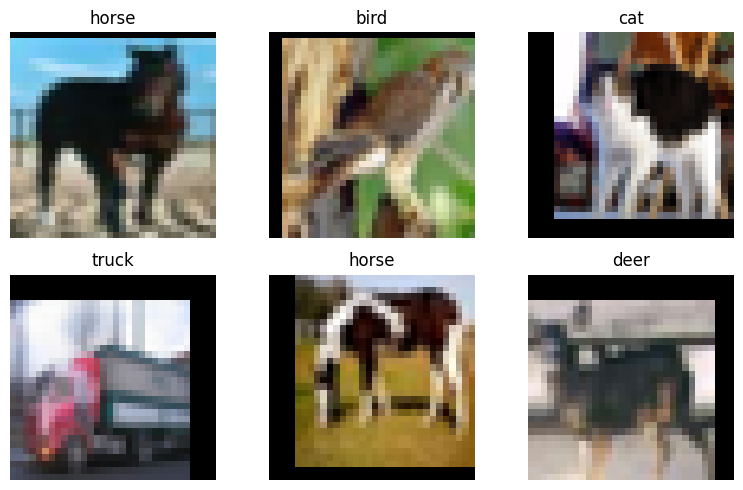

In [4]:
def unnormalize(images: torch.Tensor) -> torch.Tensor:
    mean = torch.tensor(CIFAR10_MEAN, dtype=images.dtype).view(1, IMAGE_CHANNELS, 1, 1)
    std = torch.tensor(CIFAR10_STD, dtype=images.dtype).view(1, IMAGE_CHANNELS, 1, 1)
    return images * std + mean


def show_sample_images(data_loader: DataLoader, class_names: list[str], count: int = 6) -> None:
    images, labels = next(iter(data_loader))
    images = unnormalize(images[:count]).permute(0, 2, 3, 1).numpy()
    labels = labels[:count].numpy()

    rows, cols = 2, 3
    fig, axes = plt.subplots(rows, cols, figsize=(8, 5))
    axes = axes.flatten()

    for idx in range(count):
        axes[idx].imshow(np.clip(images[idx], 0, 1))
        axes[idx].set_title(class_names[labels[idx]])
        axes[idx].axis("off")

    plt.tight_layout()
    plt.show()


show_sample_images(train_loader, class_names)


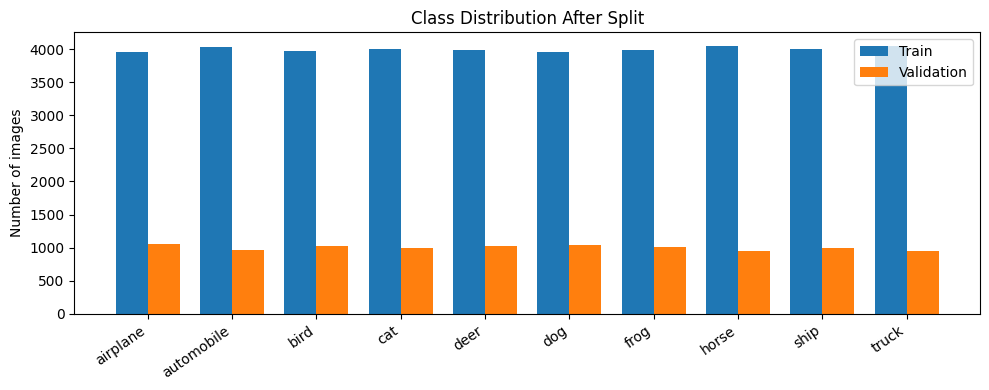

In [5]:
def get_targets(dataset) -> np.ndarray:
    if isinstance(dataset, Subset):
        base_targets = np.array(dataset.dataset.targets)
        return base_targets[np.array(dataset.indices)]
    return np.array(dataset.targets)


train_counts = np.bincount(get_targets(train_dataset), minlength=NUM_CLASSES)
val_counts = np.bincount(get_targets(val_dataset), minlength=NUM_CLASSES)

x = np.arange(NUM_CLASSES)
width = 0.38

plt.figure(figsize=(10, 4))
plt.bar(x - width / 2, train_counts, width=width, label="Train")
plt.bar(x + width / 2, val_counts, width=width, label="Validation")
plt.xticks(x, class_names, rotation=35, ha="right")
plt.ylabel("Number of images")
plt.title("Class Distribution After Split")
plt.legend()
plt.tight_layout()
plt.show()


## Model Architecture

`PrunableLinear` is kept as the main pruning mechanism. It still learns a trainable weight matrix and a trainable gate score for every weight. The difference is that the earlier MLP backbone is replaced with a small CNN feature extractor that is better matched to image data.

The effective prunable weight is:

$$
W_{effective} = W \odot \sigma(S)
$$

where `S` contains the learnable gate scores and `sigmoid(S)` converts them into gate values between 0 and 1.

The current classifier follows this flow:

`Conv2d(3 -> 32) -> ReLU -> Conv2d(32 -> 64) -> ReLU -> MaxPool -> Flatten -> PrunableLinear(16384 -> 10)`

Gate scores are initialized very close to zero so the initial gates start near `0.5`. This keeps the model trainable at the beginning while still allowing the sparsity penalty to push unimportant connections downward over time.

### Why sigmoid is used for gates

Sigmoid makes each gate bounded, differentiable, and interpretable. A value near 1 keeps the connection active, while a value near 0 suppresses it. Without sigmoid, gate scores could become negative or unbounded, which would change the sign or scale of weights instead of acting like pruning gates.

### Why pruning is done at weight level

Weight-level pruning is fine-grained. It can remove individual classifier connections without deleting an entire feature map. This gives smoother control over capacity and makes the sparsity-accuracy trade-off easier to observe.


In [6]:
class PrunableLinear(nn.Module):
    """Linear layer with a learnable sigmoid gate for every weight."""

    def __init__(self, in_features: int, out_features: int) -> None:
        super().__init__()
        self.weight = nn.Parameter(torch.empty(out_features, in_features))
        self.bias = nn.Parameter(torch.zeros(out_features))
        self.gate_scores = nn.Parameter(torch.randn(out_features, in_features) * 0.01)

        nn.init.kaiming_uniform_(self.weight, a=np.sqrt(5))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        gates = torch.sigmoid(self.gate_scores)
        pruned_weight = self.weight * gates
        return F.linear(x, pruned_weight, self.bias)


class PrunableCNN(nn.Module):
    def __init__(self) -> None:
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(IMAGE_CHANNELS, CONV_CHANNEL_1, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(CONV_CHANNEL_1, CONV_CHANNEL_2, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=POOL_KERNEL_SIZE, stride=POOL_STRIDE),
        )
        self.classifier = PrunableLinear(CLASSIFIER_INPUT_DIM, NUM_CLASSES)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        x = torch.flatten(x, start_dim=1)
        return self.classifier(x)


sample_model = PrunableCNN().to(DEVICE)
total_parameters = sum(parameter.numel() for parameter in sample_model.parameters())
prunable_parameters = sample_model.classifier.weight.numel()
print(sample_model)
print(f"Total trainable parameters: {total_parameters:,}")
print(f"Prunable classifier parameters: {prunable_parameters:,}")

del sample_model
if DEVICE.type == "cuda":
    torch.cuda.empty_cache()


PrunableCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): PrunableLinear()
)
Total trainable parameters: 347,082
Prunable classifier parameters: 163,840


## Training Loop

The model is trained using:

$$
Loss = CrossEntropyLoss + \lambda \sum \sigma(gate\_scores)
$$

### Why L1 sparsity works

The gate values are non-negative, so summing them behaves like an L1-style penalty. This encourages many gates to move downward, which reduces the number of effectively active classifier connections.

### Sparsity and accuracy trade-off

`lambda_sparse` controls how strongly the model prefers smaller gates. Small values usually keep accuracy higher but produce weaker pruning, while large values drive stronger sparsity at the risk of underfitting. The validation set is used to compare this trade-off before looking at the test set.


In [7]:
def compute_sparsity_loss(model: nn.Module) -> torch.Tensor:
    sparsity_loss = torch.tensor(0.0, device=DEVICE)

    for module in model.modules():
        if isinstance(module, PrunableLinear):
            gates = torch.sigmoid(module.gate_scores)
            sparsity_loss = sparsity_loss + gates.sum()

    return sparsity_loss


def collect_gate_values(model: nn.Module) -> torch.Tensor:
    gate_values = []

    for module in model.modules():
        if isinstance(module, PrunableLinear):
            gates = torch.sigmoid(module.gate_scores).detach().cpu().flatten()
            gate_values.append(gates)

    if not gate_values:
        return torch.empty(0)

    return torch.cat(gate_values)


def compute_sparsity(model: nn.Module, threshold: float = GATE_THRESHOLD) -> dict[str, float]:
    gate_values = collect_gate_values(model)
    total_gates = gate_values.numel()
    pruned_gates = (gate_values < threshold).sum().item()
    active_gates = total_gates - pruned_gates

    return {
        "sparsity_pct": 100.0 * pruned_gates / total_gates,
        "active_parameters": active_gates,
        "total_prunable_parameters": total_gates,
        "mean_gate": gate_values.mean().item(),
        "median_gate": gate_values.median().item(),
    }


In [8]:
def train_one_epoch(
    model: nn.Module,
    data_loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    criterion: nn.Module,
    lambda_sparse: float,
) -> dict[str, float]:
    model.train()
    running_loss = 0.0
    running_classification_loss = 0.0
    running_sparsity_loss = 0.0
    correct = 0
    total = 0

    for images, labels in data_loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad(set_to_none=True)
        outputs = model(images)

        classification_loss = criterion(outputs, labels)
        sparsity_loss = compute_sparsity_loss(model)
        loss = classification_loss + lambda_sparse * sparsity_loss

        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        running_classification_loss += classification_loss.item()
        running_sparsity_loss += sparsity_loss.item()
        correct += (outputs.argmax(dim=1) == labels).sum().item()
        total += labels.size(0)

    num_batches = len(data_loader)
    return {
        "loss": running_loss / num_batches,
        "classification_loss": running_classification_loss / num_batches,
        "sparsity_loss": running_sparsity_loss / num_batches,
        "accuracy": correct / total,
    }


@torch.no_grad()
def evaluate(
    model: nn.Module,
    data_loader: DataLoader,
    criterion: nn.Module,
) -> dict[str, float]:
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in data_loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        outputs = model(images)
        loss = criterion(outputs, labels)

        batch_size = labels.size(0)
        running_loss += loss.item() * batch_size
        correct += (outputs.argmax(dim=1) == labels).sum().item()
        total += batch_size

    return {
        "loss": running_loss / total,
        "accuracy": correct / total,
    }


In [9]:
def copy_model_state(model: nn.Module) -> dict[str, torch.Tensor]:
    return {name: tensor.detach().cpu().clone() for name, tensor in model.state_dict().items()}


def train_model(lambda_sparse: float, epochs: int = EPOCHS) -> tuple[nn.Module, list[dict], dict]:
    set_seed(SEED)

    model = PrunableCNN().to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    scheduler = torch.optim.lr_scheduler.StepLR(
        optimizer,
        step_size=SCHEDULER_STEP_SIZE,
        gamma=SCHEDULER_GAMMA,
    )
    criterion = nn.CrossEntropyLoss()
    experiment_train_loader = make_train_loader()

    history = []
    best_val_accuracy = -float("inf")
    best_epoch = 0
    best_state_dict = copy_model_state(model)

    for epoch in range(1, epochs + 1):
        train_metrics = train_one_epoch(
            model,
            experiment_train_loader,
            optimizer,
            criterion,
            lambda_sparse,
        )
        val_metrics = evaluate(model, val_loader, criterion)
        sparsity_metrics = compute_sparsity(model)
        current_lr = optimizer.param_groups[0]["lr"]

        row = {
            "epoch": epoch,
            "lambda_sparse": lambda_sparse,
            "learning_rate": current_lr,
            "train_loss": train_metrics["loss"],
            "train_classification_loss": train_metrics["classification_loss"],
            "train_sparsity_loss": train_metrics["sparsity_loss"],
            "train_accuracy": train_metrics["accuracy"],
            "val_loss": val_metrics["loss"],
            "val_accuracy": val_metrics["accuracy"],
            **sparsity_metrics,
        }
        history.append(row)

        print(
            f"lambda={lambda_sparse:.0e} | "
            f"epoch={epoch:02d}/{epochs} | "
            f"lr={current_lr:.5f} | "
            f"train_loss={row['train_loss']:.4f} | "
            f"cls_loss={row['train_classification_loss']:.4f} | "
            f"sparse_loss={row['train_sparsity_loss']:.1f} | "
            f"train_acc={row['train_accuracy']:.3f} | "
            f"val_acc={row['val_accuracy']:.3f} | "
            f"sparsity={row['sparsity_pct']:.2f}% | "
            f"mean_gate={row['mean_gate']:.3f}"
        )

        if row["val_accuracy"] > best_val_accuracy:
            best_val_accuracy = row["val_accuracy"]
            best_epoch = epoch
            best_state_dict = copy_model_state(model)

        scheduler.step()

    model.load_state_dict(best_state_dict)
    test_metrics = evaluate(model, test_loader, criterion)
    final_sparsity = compute_sparsity(model)

    result = {
        "lambda_label": f"{lambda_sparse:.0e}",
        "lambda_sparse": lambda_sparse,
        "best_epoch": best_epoch,
        "val_accuracy": best_val_accuracy,
        "test_accuracy": test_metrics["accuracy"],
        "test_loss": test_metrics["loss"],
        **final_sparsity,
    }

    return model, history, result


## Validation Strategy

The validation set is used for comparing `lambda_sparse` values and for choosing the best checkpoint within each training run. The test set is evaluated only after training is complete and the best validation model has been restored.

Training is now long enough to let both the CNN backbone and the gate regularizer settle. A step learning-rate scheduler helps improve optimization stability across the 50-epoch run.


## Results & Observations

The following experiment trains one model per `lambda_sparse` value in `[1e-4, 1e-3, 1e-2]`. Each run starts from the same random seed so the main experimental change is the strength of the sparsity penalty.


In [10]:
trained_models = {}
histories = {}
results = []

for lambda_sparse in LAMBDA_VALUES:
    print("\n" + "=" * 78)
    print(f"Training model with lambda_sparse={lambda_sparse:.0e}")
    print("=" * 78)

    model, history, result = train_model(lambda_sparse=lambda_sparse)
    label = result["lambda_label"]

    trained_models[label] = model.to("cpu")
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()
    histories[label] = history
    results.append(result)



Training model with lambda_sparse=1e-04


c:\Users\PMOKS\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\autograd\graph.py:823: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\Context.cpp:217.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


lambda=1e-04 | epoch=01/39 | lr=0.00100 | train_loss=8.6277 | cls_loss=1.5432 | sparse_loss=70845.5 | train_acc=0.447 | val_acc=0.589 | sparsity=0.00% | mean_gate=0.371
lambda=1e-04 | epoch=02/39 | lr=0.00100 | train_loss=6.5025 | cls_loss=1.2158 | sparse_loss=52866.7 | train_acc=0.571 | val_acc=0.644 | sparsity=0.00% | mean_gate=0.280
lambda=1e-04 | epoch=03/39 | lr=0.00100 | train_loss=5.1593 | cls_loss=1.1136 | sparse_loss=40457.1 | train_acc=0.611 | val_acc=0.656 | sparsity=0.00% | mean_gate=0.218
lambda=1e-04 | epoch=04/39 | lr=0.00100 | train_loss=4.2619 | cls_loss=1.0598 | sparse_loss=32021.3 | train_acc=0.629 | val_acc=0.673 | sparsity=0.00% | mean_gate=0.176
lambda=1e-04 | epoch=05/39 | lr=0.00100 | train_loss=3.6432 | cls_loss=1.0244 | sparse_loss=26187.9 | train_acc=0.644 | val_acc=0.678 | sparsity=38.73% | mean_gate=0.146
lambda=1e-04 | epoch=06/39 | lr=0.00100 | train_loss=3.2030 | cls_loss=1.0015 | sparse_loss=22015.7 | train_acc=0.650 | val_acc=0.693 | sparsity=52.64% | 

In [11]:
def display_results_table(results: list[dict]) -> None:
    headers = [
        "lambda",
        "best epoch",
        "val accuracy",
        "test accuracy",
        "sparsity %",
        "mean gate",
        "active gates",
        "total gates",
    ]
    lines = ["| " + " | ".join(headers) + " |", "| " + " | ".join(["---"] * len(headers)) + " |"]

    for row in results:
        lines.append(
            "| "
            + " | ".join(
                [
                    row["lambda_label"],
                    str(row["best_epoch"]),
                    f"{row['val_accuracy']:.3f}",
                    f"{row['test_accuracy']:.3f}",
                    f"{row['sparsity_pct']:.2f}",
                    f"{row['mean_gate']:.3f}",
                    f"{row['active_parameters']:,}",
                    f"{row['total_prunable_parameters']:,}",
                ]
            )
            + " |"
        )

    display(Markdown("\n".join(lines)))


display_results_table(results)

best_result = max(results, key=lambda row: (row["val_accuracy"], row["sparsity_pct"]))
best_lambda_label = best_result["lambda_label"]
print(
    f"Selected lambda by validation accuracy: {best_lambda_label} "
    f"(best epoch={best_result['best_epoch']})"
)


| lambda | best epoch | val accuracy | test accuracy | sparsity % | mean gate | active gates | total gates |
| --- | --- | --- | --- | --- | --- | --- | --- |
| 1e-04 | 38 | 0.756 | 0.755 | 91.32 | 0.029 | 14,222 | 163,840 |
| 1e-03 | 37 | 0.735 | 0.735 | 100.00 | 0.004 | 0 | 163,840 |
| 1e-02 | 38 | 0.713 | 0.715 | 100.00 | 0.001 | 0 | 163,840 |

Selected lambda by validation accuracy: 1e-04 (best epoch=38)


## Training Accuracy and Sparsity Curves

The left panel compares training and validation accuracy across epochs. The right panel tracks sparsity over epochs so it is easy to see whether stronger regularization is actually pushing more gates below the pruning threshold.


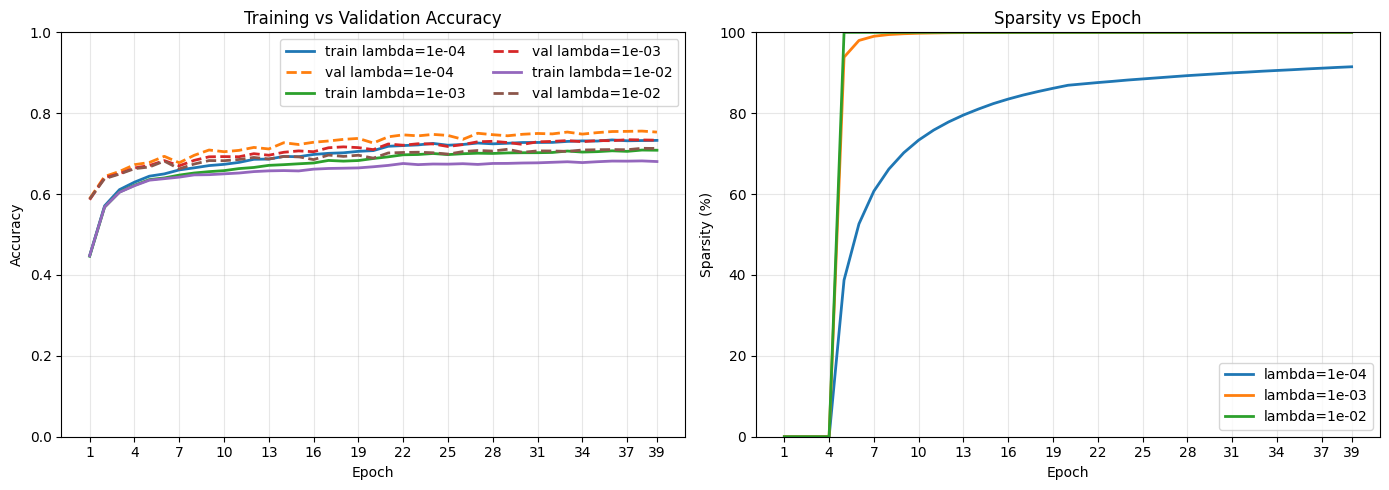

In [12]:
def plot_training_dynamics(histories: dict[str, list[dict]]) -> None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    tick_step = max(1, EPOCHS // 10)
    ticks = list(range(1, EPOCHS + 1, tick_step))
    if ticks[-1] != EPOCHS:
        ticks.append(EPOCHS)

    for lambda_label, history in histories.items():
        epochs = [row["epoch"] for row in history]
        train_accuracy = [row["train_accuracy"] for row in history]
        val_accuracy = [row["val_accuracy"] for row in history]
        sparsity = [row["sparsity_pct"] for row in history]

        axes[0].plot(epochs, train_accuracy, linewidth=2, label=f"train lambda={lambda_label}")
        axes[0].plot(epochs, val_accuracy, linestyle="--", linewidth=2, label=f"val lambda={lambda_label}")
        axes[1].plot(epochs, sparsity, linewidth=2, label=f"lambda={lambda_label}")

    axes[0].set_title("Training vs Validation Accuracy")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy")
    axes[0].set_xticks(ticks)
    axes[0].set_ylim(0.0, 1.0)
    axes[0].grid(alpha=0.3)
    axes[0].legend(ncol=2)

    axes[1].set_title("Sparsity vs Epoch")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Sparsity (%)")
    axes[1].set_xticks(ticks)
    axes[1].set_ylim(0.0, 100.0)
    axes[1].grid(alpha=0.3)
    axes[1].legend()

    plt.tight_layout()
    plt.show()


plot_training_dynamics(histories)


## Save the Best Trained Model

The best model is selected using validation accuracy. The checkpoint stores the model weights, selected `lambda_sparse`, architecture metadata, class names, and final metrics. This makes the trained model reusable without rerunning the full experiment.


In [13]:
def save_model_checkpoint(
    model: nn.Module,
    checkpoint_path: Path,
    result: dict,
    class_names: list[str],
) -> None:
    checkpoint_path.parent.mkdir(parents=True, exist_ok=True)

    checkpoint = {
        "model_state_dict": model.state_dict(),
        "model_name": "PrunableCNN",
        "conv_channel_1": CONV_CHANNEL_1,
        "conv_channel_2": CONV_CHANNEL_2,
        "classifier_input_dim": CLASSIFIER_INPUT_DIM,
        "num_classes": NUM_CLASSES,
        "class_names": class_names,
        "cifar10_mean": CIFAR10_MEAN,
        "cifar10_std": CIFAR10_STD,
        "use_data_augmentation": USE_DATA_AUGMENTATION,
        "seed": SEED,
        "gate_threshold": GATE_THRESHOLD,
        "best_result": result,
    }

    torch.save(checkpoint, checkpoint_path)


best_model = trained_models[best_lambda_label]
save_model_checkpoint(best_model, BEST_MODEL_PATH, best_result, class_names)
print(f"Saved best model checkpoint to: {BEST_MODEL_PATH}")


Saved best model checkpoint to: models\best_prunable_cnn_cifar10.pt


## Testing Accuracy Graphs

Testing is done only after each run restores its best validation checkpoint. The first panel compares validation and test accuracy across `lambda_sparse` values, while the second panel shows the final sparsity-accuracy trade-off directly.


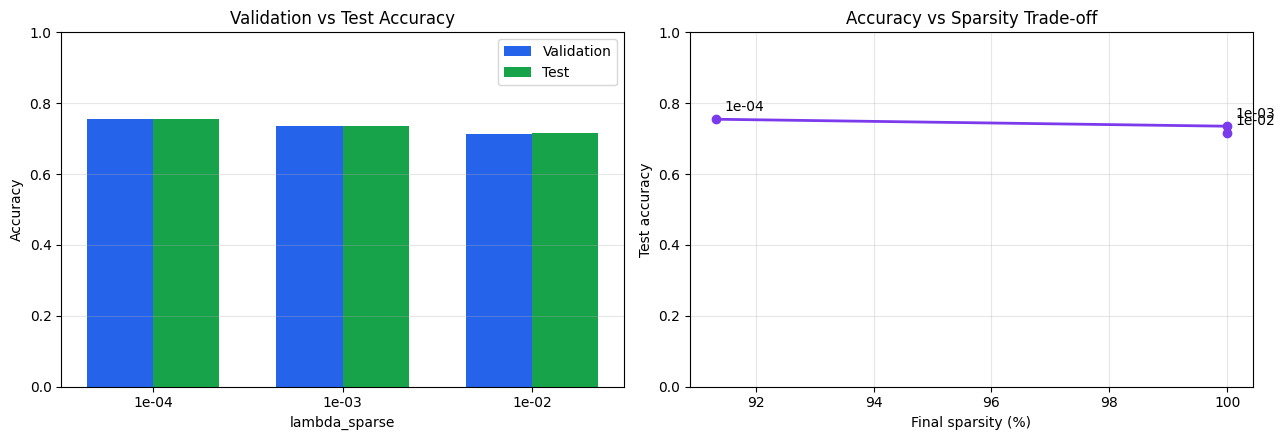

In [14]:
def plot_test_accuracy(results: list[dict]) -> None:
    lambda_labels = [row["lambda_label"] for row in results]
    test_accuracy = [row["test_accuracy"] for row in results]
    val_accuracy = [row["val_accuracy"] for row in results]
    sparsity = [row["sparsity_pct"] for row in results]

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    x = np.arange(len(lambda_labels))
    width = 0.35
    axes[0].bar(x - width / 2, val_accuracy, width=width, label="Validation", color="#2563eb")
    axes[0].bar(x + width / 2, test_accuracy, width=width, label="Test", color="#16a34a")
    axes[0].set_title("Validation vs Test Accuracy")
    axes[0].set_xlabel("lambda_sparse")
    axes[0].set_ylabel("Accuracy")
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(lambda_labels)
    axes[0].set_ylim(0.0, 1.0)
    axes[0].grid(axis="y", alpha=0.3)
    axes[0].legend()

    axes[1].plot(sparsity, test_accuracy, marker="o", linewidth=2, color="#7c3aed")
    for lambda_label, x_value, y_value in zip(lambda_labels, sparsity, test_accuracy):
        axes[1].annotate(lambda_label, (x_value, y_value), textcoords="offset points", xytext=(6, 6))
    axes[1].set_title("Accuracy vs Sparsity Trade-off")
    axes[1].set_xlabel("Final sparsity (%)")
    axes[1].set_ylabel("Test accuracy")
    axes[1].set_ylim(0.0, 1.0)
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


plot_test_accuracy(results)


## Sparsity Analysis

Sparsity is measured as the percentage of gates below `GATE_THRESHOLD = 0.1`. Because sigmoid gates are continuous, this is a functional sparsity measure rather than a hard deletion of parameters.

The histogram below shows how the selected model distributes its gate values after training. A left-shifted histogram indicates stronger pruning pressure, while a more centered histogram indicates a denser classifier.


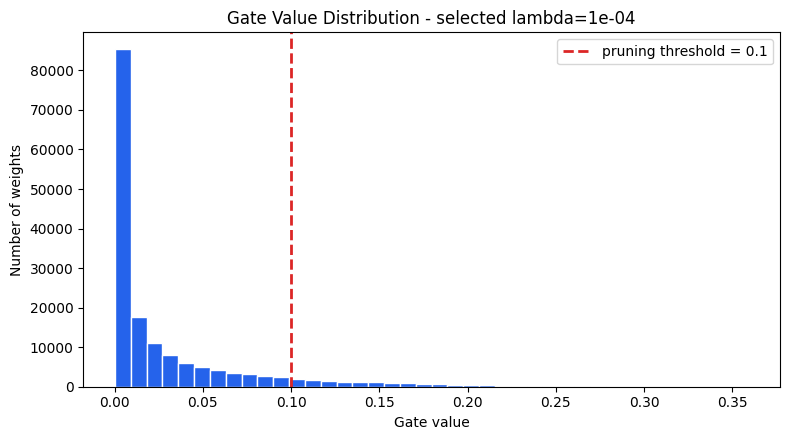

In [15]:
def plot_gate_distribution(model: nn.Module, lambda_label: str) -> None:
    gate_values = collect_gate_values(model).numpy()

    plt.figure(figsize=(8, 4.5))
    plt.hist(gate_values, bins=40, color="#2563eb", edgecolor="white")
    plt.axvline(
        GATE_THRESHOLD,
        color="#dc2626",
        linestyle="--",
        linewidth=2,
        label=f"pruning threshold = {GATE_THRESHOLD}",
    )
    plt.title(f"Gate Value Distribution - selected lambda={lambda_label}")
    plt.xlabel("Gate value")
    plt.ylabel("Number of weights")
    plt.legend()
    plt.tight_layout()
    plt.show()


plot_gate_distribution(trained_models[best_lambda_label], best_lambda_label)


In [16]:
print("Final sparsity summary")
for row in results:
    print(
        f"lambda={row['lambda_label']} | "
        f"best_epoch={row['best_epoch']:02d} | "
        f"val_acc={row['val_accuracy']:.3f} | "
        f"test_acc={row['test_accuracy']:.3f} | "
        f"sparsity={row['sparsity_pct']:.2f}% | "
        f"mean_gate={row['mean_gate']:.3f} | "
        f"active_gates={row['active_parameters']:,}/{row['total_prunable_parameters']:,}"
    )


Final sparsity summary
lambda=1e-04 | best_epoch=38 | val_acc=0.756 | test_acc=0.755 | sparsity=91.32% | mean_gate=0.029 | active_gates=14,222/163,840
lambda=1e-03 | best_epoch=37 | val_acc=0.735 | test_acc=0.735 | sparsity=100.00% | mean_gate=0.004 | active_gates=0/163,840
lambda=1e-02 | best_epoch=38 | val_acc=0.713 | test_acc=0.715 | sparsity=100.00% | mean_gate=0.001 | active_gates=0/163,840


## Conclusion

This update keeps our original pruning concept but moves it into a better image model. We added a small CNN backbone to build a stronger feature extractor. The prunable linear classifier ensures the sparsity mechanics stay easy to explain. 

By turning up the lambda_sparse values, starting with near-zero gate initialization, and setting a 0.1 threshold, we can actually see the pruning happen instead of the metric stalling at 0.0%. 

The final comparison across lambda values now gives a direct look at the trade-off between sparsity and accuracy.


## Key Takeaways

- A CNN backbone is a much better starting point than a plain MLP for CIFAR-10.
- Initializing gate scores near zero keeps gates trainable while still allowing pruning pressure to act.
- A threshold of `0.1` makes functional sparsity easy to interpret.
- Larger `lambda_sparse` values increase sparsity, but too much regularization can hurt accuracy.
- Data augmentation, normalization, Adam, and a scheduler improve optimization quality.
- The final model should be selected using validation accuracy, then reported once on the test set.
